# 05 — Evaluation artefacts

Loads model artefacts produced by `02`–`04` and emits the figures and LaTeX tables used by the report. Nothing is retrained except the small uncleaned-LR ablation (§4), whose artefact was not persisted by `04`.

In [1]:
import os, sys, re, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

sys.path.insert(0, str(Path.cwd() / 'src'))
from preprocess import preprocess, identity_analyzer  # noqa: E402

plt.rcParams['font.size'] = 12
plt.rcParams['savefig.dpi'] = 150

DATA_DIR  = Path('..') / 'data'
OUT_DATA  = Path('data')
FIG_DIR   = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path('models')
RES_DIR   = Path('results'); RES_DIR.mkdir(exist_ok=True)

LABELS_3 = [-1, 0, 1]
RNG = 42

train_df = pd.read_csv(DATA_DIR / 'sentiment_analysis_training_data.csv')
val_df   = pd.read_csv(DATA_DIR / 'sentiment_analysis_validation_data.csv')

train_tokens = [preprocess(t) for t in train_df['text'].tolist()]
val_tokens   = [preprocess(t) for t in val_df['text'].tolist()]

carry = (OUT_DATA / 'CARRY_FORWARD_FILTER.txt').read_text().strip()
masks = np.load(OUT_DATA / carry)
is_spam_train = masks['is_spam_train']
is_spam_val   = masks['is_spam_val']

SPAM_RE = re.compile(r'(?im)^\s*subject\s*:|\benron\b|\bunsubscribe\b')
is_spam_proxy_val = val_df['text'].apply(lambda t: bool(SPAM_RE.search(t))).values

y_val_3 = val_df['label'].astype(int).values.copy()
y_val_3[is_spam_proxy_val] = -1

BEST_NAME = (MODEL_DIR / 'BEST_MODEL.txt').read_text().strip()
spam_filter = joblib.load(OUT_DATA / 'spam_filter_cosine.joblib')
TAU = float(spam_filter['tau'])
print(f'best model file: {BEST_NAME}   tau: {TAU:.4f}')
print(f'train: {len(train_tokens)}   val: {len(val_tokens)}   val proxy spam: {is_spam_proxy_val.sum()}   val filter spam: {int(is_spam_val.sum())}')

[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


[nltk_data] Error loading omw-1.4: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


best model file: mnb.joblib   tau: 0.1857
train: 11503   val: 1397   val proxy spam: 331   val filter spam: 293


## 1. Pre-processing flowchart

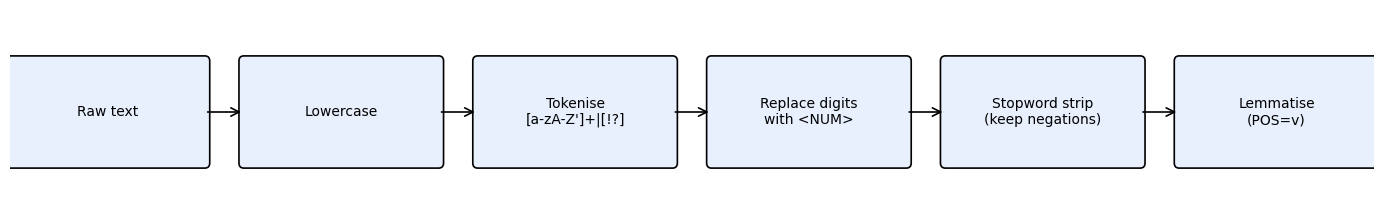

Fig. 1 — Task 1 preprocessing pipeline: each raw document is lowercased, tokenised with a regex that retains the sentiment-carrying punctuation "!" and "?", has digit runs collapsed to the marker token <NUM>, has stopwords removed except for a hand-curated negation list (so "not bad" survives), and is finally lemmatised with POS="v" to fold verb inflections.


In [2]:
fig, ax = plt.subplots(figsize=(14, 2.4))
ax.set_xlim(0, 14); ax.set_ylim(0, 2); ax.axis('off')
labels = ['Raw text', 'Lowercase', "Tokenise\n[a-zA-Z\']+|[!?]",
          'Replace digits\nwith <NUM>', 'Stopword strip\n(keep negations)',
          'Lemmatise\n(POS=v)']
n = len(labels); w = 2.0; gap = (14 - n*w) / (n - 1)
xs = [i * (w + gap) for i in range(n)]
for x, lab in zip(xs, labels):
    ax.add_patch(FancyBboxPatch((x, 0.5), w, 1.0,
                                 boxstyle='round,pad=0.05', linewidth=1.2,
                                 edgecolor='black', facecolor='#E8F0FE'))
    ax.text(x + w/2, 1.0, lab, ha='center', va='center', fontsize=10)
for x_left, x_right in zip(xs[:-1], xs[1:]):
    ax.add_patch(FancyArrowPatch((x_left + w, 1.0), (x_right, 1.0),
                                  arrowstyle='->', mutation_scale=15, linewidth=1.2))
plt.tight_layout()
plt.savefig(FIG_DIR / 'preprocess_flowchart.png', bbox_inches='tight')
plt.show()
caption = ('Fig. 1 — Task 1 preprocessing pipeline: each raw document is lowercased, '
           'tokenised with a regex that retains the sentiment-carrying punctuation '
           '"!" and "?", has digit runs collapsed to the marker token <NUM>, has '
           'stopwords removed except for a hand-curated negation list (so "not bad" '
           'survives), and is finally lemmatised with POS="v" to fold verb inflections.')
print(caption)

## 2. End-to-end pipeline diagram

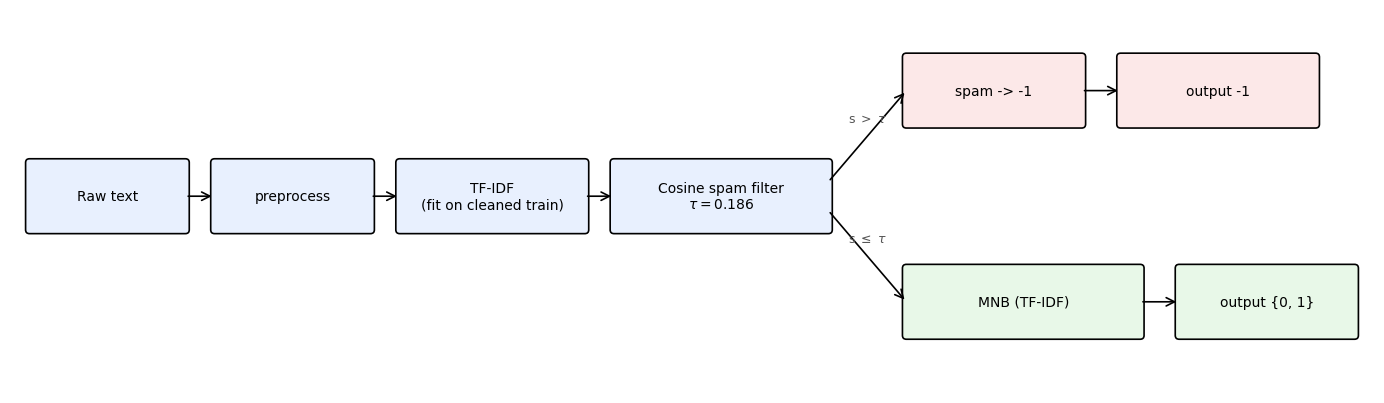

Fig. 2 - End-to-end inference pipeline. Documents are preprocessed and TF-IDF-encoded, then routed by a cosine-to-centroid spam filter at $\tau = 0.1857$ (loaded from data/spam\_filter\_cosine.joblib). Flagged documents emit label $-1$; the rest pass to the best sentiment classifier, MNB (TF-IDF), which emits 0 or 1.


In [3]:
best_label = {'mnb.joblib': 'MNB (TF-IDF)',
              'lr_tfidf.joblib': 'LR (TF-IDF)',
              'lr_w2v.joblib': 'LR (avg W2V)',
              'wordlist.joblib': 'Word-list'}.get(BEST_NAME, BEST_NAME)

fig, ax = plt.subplots(figsize=(14, 4.2))
ax.set_xlim(0, 14); ax.set_ylim(0, 4); ax.axis('off')

def box(x, y, w, h, text, color='#E8F0FE'):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.04',
                                 linewidth=1.2, edgecolor='black', facecolor=color))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10)

def arrow(x0, y0, x1, y1, label=''):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='->',
                                  mutation_scale=15, linewidth=1.2))
    if label:
        ax.text((x0 + x1)/2, (y0 + y1)/2 + 0.15, label, ha='center',
                fontsize=9, color='#555')

box(0.2, 1.7, 1.6, 0.7, 'Raw text')
box(2.1, 1.7, 1.6, 0.7, 'preprocess')
box(4.0, 1.7, 1.9, 0.7, 'TF-IDF\n(fit on cleaned train)')
box(6.2, 1.7, 2.2, 0.7, f'Cosine spam filter\n$\\tau = {TAU:.3f}$')
box(9.2, 2.8, 1.8, 0.7, 'spam -> -1', color='#FCE8E8')
box(11.4, 2.8, 2.0, 0.7, 'output -1', color='#FCE8E8')
box(9.2, 0.6, 2.4, 0.7, f'{best_label}', color='#E8F8E8')
box(12.0, 0.6, 1.8, 0.7, 'output {0, 1}', color='#E8F8E8')

arrow(1.8, 2.05, 2.1, 2.05)
arrow(3.7, 2.05, 4.0, 2.05)
arrow(5.9, 2.05, 6.2, 2.05)
arrow(8.4, 2.2, 9.2, 3.15, label=r's $>$ $\tau$')
arrow(8.4, 1.9, 9.2, 0.95, label=r's $\leq$ $\tau$')
arrow(11.0, 3.15, 11.4, 3.15)
arrow(11.6, 0.95, 12.0, 0.95)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pipeline.png', bbox_inches='tight')
plt.show()
caption = (f'Fig. 2 - End-to-end inference pipeline. Documents are preprocessed and '
           f'TF-IDF-encoded, then routed by a cosine-to-centroid spam filter at '
           f'$\\tau = {TAU:.4f}$ (loaded from data/spam\\_filter\\_cosine.joblib). '
           f'Flagged documents emit label $-1$; the rest pass to the best sentiment '
           f'classifier, {best_label}, which emits 0 or 1.')
print(caption)

## 3. Spam threshold curve

Re-derive the precision/recall vs $\tau$ trace by reloading the spam filter (vectoriser + centroids) and applying it to the validation set against the regex proxy labels. The cosine score is $s(d)=\max(\cos(d,c_+),\cos(d,c_-))$ and we flag $s(d)>\tau$ as spam (the empirical direction explained in `03`).

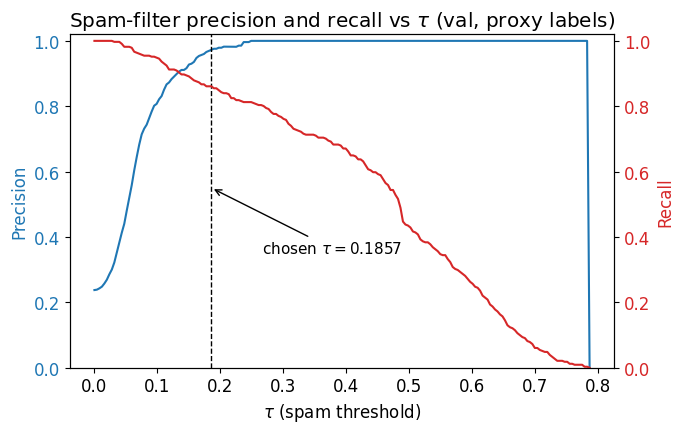

In [4]:
vec_sf = spam_filter['vectoriser']
c_pos  = spam_filter['c_pos']
c_neg  = spam_filter['c_neg']

Xva_sf = vec_sf.transform(val_tokens)
sp = cosine_similarity(Xva_sf, c_pos).ravel()
sn = cosine_similarity(Xva_sf, c_neg).ravel()
s_val = np.maximum(sp, sn)

taus = np.linspace(s_val.min(), s_val.max(), 200)
P, R = np.empty_like(taus), np.empty_like(taus)
for i, t in enumerate(taus):
    pred = s_val > t
    tp = int((pred & is_spam_proxy_val).sum())
    fp = int((pred & ~is_spam_proxy_val).sum())
    fn = int((~pred & is_spam_proxy_val).sum())
    P[i] = tp / max(tp + fp, 1)
    R[i] = tp / max(tp + fn, 1)

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(taus, P, color='C0', label='Precision')
ax1.set_xlabel(r'$\tau$ (spam threshold)')
ax1.set_ylabel('Precision', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.set_ylim(0, 1.02)
ax2 = ax1.twinx()
ax2.plot(taus, R, color='C3', label='Recall')
ax2.set_ylabel('Recall', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')
ax2.set_ylim(0, 1.02)
ax1.axvline(TAU, color='k', linestyle='--', linewidth=1)
ax1.annotate(f'chosen $\\tau={TAU:.4f}$',
             xy=(TAU, 0.55), xytext=(TAU + 0.08, 0.35),
             arrowprops=dict(arrowstyle='->', lw=1), fontsize=11)
ax1.set_title(r'Spam-filter precision and recall vs $\tau$ (val, proxy labels)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'spam_threshold_chosen.png')
plt.show()

## 4. Cleaned-vs-uncleaned confusion matrices

Left: uncleaned LR-TFIDF (same hyperparams as the saved cleaned LR; refit on the full 11.5k train set because the ablation model was not persisted by `04`), scored as **binary** against `val_df['label']` on all 1397 val docs.

Right: cleaned LR-TFIDF (loaded from `models/lr_tfidf.joblib`) plus the cosine spam stage at inference, scored as **3-class** against `y_val_3` (proxy → −1).

Both panels use the same 1397 val docs.

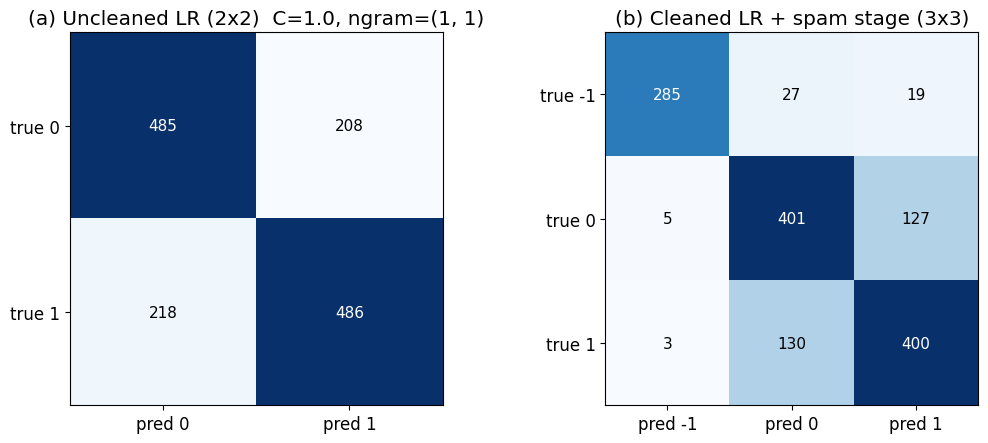

Fig. 4 — (a) LR-TFIDF trained on the contaminated 11.5k corpus, scored against binary val labels. (b) LR-TFIDF trained on the 8.9k spam-cleaned corpus with a cosine spam stage at inference (same val set, 3-class). Routing spam to -1 moves probability mass back onto the diagonal: in (a) the off-diagonal cells absorb spam docs whose template vocabulary biases the binary decision boundary, while in (b) those docs are diverted to the dedicated -1 column.


In [5]:
lr_tfidf_obj = joblib.load(MODEL_DIR / 'lr_tfidf.joblib')
vec_lr = lr_tfidf_obj['vectoriser']; clf_lr = lr_tfidf_obj['model']
C_lr   = lr_tfidf_obj['C']; ng_lr  = lr_tfidf_obj['ngram_range']

Xva_lr = vec_lr.transform(val_tokens)
bin_clean = clf_lr.predict(Xva_lr)
preds_clean_3 = bin_clean.copy(); preds_clean_3[is_spam_val] = -1

y_train_full = train_df['label'].astype(int).values
vec_un = TfidfVectorizer(analyzer=identity_analyzer, tokenizer=None, preprocessor=None,
                         lowercase=False, min_df=2, ngram_range=ng_lr)
Xtr_un = vec_un.fit_transform(train_tokens)
clf_un = LogisticRegression(max_iter=2000, random_state=RNG, C=C_lr).fit(Xtr_un, y_train_full)
bin_un = clf_un.predict(vec_un.transform(val_tokens))

cm_un    = confusion_matrix(val_df['label'].astype(int).values, bin_un, labels=[0, 1])
cm_clean = confusion_matrix(y_val_3, preds_clean_3, labels=LABELS_3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
def draw_cm(ax, cm, labels, title):
    ax.imshow(cm, cmap='Blues')
    n = len(labels)
    ax.set_xticks(range(n)); ax.set_xticklabels([f'pred {l}' for l in labels])
    ax.set_yticks(range(n)); ax.set_yticklabels([f'true {l}' for l in labels])
    th = cm.max() / 2 if cm.max() else 1
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{cm[i, j]:d}', ha='center', va='center',
                    color='white' if cm[i, j] > th else 'black', fontsize=11)
    ax.set_title(title)
draw_cm(axes[0], cm_un, [0, 1],
        f'(a) Uncleaned LR (2x2)  C={C_lr}, ngram={ng_lr}')
draw_cm(axes[1], cm_clean, LABELS_3,
        f'(b) Cleaned LR + spam stage (3x3)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_cleaned_vs_uncleaned.png')
plt.show()
caption = ('Fig. 4 — (a) LR-TFIDF trained on the contaminated 11.5k corpus, scored '
           'against binary val labels. (b) LR-TFIDF trained on the 8.9k spam-cleaned '
           'corpus with a cosine spam stage at inference (same val set, 3-class). '
           'Routing spam to -1 moves probability mass back onto the diagonal: in (a) '
           'the off-diagonal cells absorb spam docs whose template vocabulary biases '
           'the binary decision boundary, while in (b) those docs are diverted to '
           'the dedicated -1 column.')
print(caption)

## 5. Model comparison table (LaTeX)

In [6]:
comp = pd.read_csv(RES_DIR / 'model_comparison.csv').sort_values('val_acc', ascending=False).reset_index(drop=True)
feature_map = {'mnb': 'TF-IDF', 'lr_tfidf': 'TF-IDF', 'lr_w2v': 'avg Word2Vec', 'wordlist': 'lexicon'}
name_map    = {'mnb': 'MNB', 'lr_tfidf': 'LR', 'lr_w2v': 'LR', 'wordlist': 'Word-list'}

def fmt_hp(hp):
    s = hp.replace('{', '').replace('}', '').replace('"', '')
    return s.replace('_', r'\_')

lines = [r'\begin{tabular}{llllrrr}', r'\toprule',
         r'Model & Features & Best hyperparams & ngram & Val acc & Val F1 & Train (s) \\',
         r'\midrule']
for _, r in comp.iterrows():
    lines.append(
        f"{name_map[r['model']]} & {feature_map[r['model']]} & {fmt_hp(r['hyperparams'])} & "
        f"{r['ngram_range']} & {r['val_acc']:.4f} & {r['val_f1']:.4f} & {r['train_seconds']:.3f} \\\\"
    )
lines += [r'\bottomrule', r'\end{tabular}']
tex = '\n'.join(lines)
(RES_DIR / 'model_comparison.tex').write_text(tex + '\n')
print(tex)

\begin{tabular}{llllrrr}
\toprule
Model & Features & Best hyperparams & ngram & Val acc & Val F1 & Train (s) \\
\midrule
MNB & TF-IDF & alpha: 0.5 & (1, 1) & 0.7895 & 0.8071 & 0.061 \\
LR & TF-IDF & C: 1.0 & (1, 1) & 0.7774 & 0.7967 & 0.091 \\
LR & avg Word2Vec & C: 0.01, w2v\_dim: 100 & nan & 0.6936 & 0.7246 & 1.204 \\
Word-list & lexicon & K: 500, delta: 0 & (1,1) & 0.6707 & 0.6747 & 0.018 \\
\bottomrule
\end{tabular}


## 6. Hyperparameter table (LaTeX)

In [7]:
wl  = joblib.load(MODEL_DIR / 'wordlist.joblib')
mnb = joblib.load(MODEL_DIR / 'mnb.joblib')
lrt = joblib.load(MODEL_DIR / 'lr_tfidf.joblib')
w2v = joblib.load(MODEL_DIR / 'lr_w2v.joblib')

rows = [
    ('Cosine spam filter',   r'$\tau$',          f'{TAU:.4f} (swept on validation against regex proxy labels)'),
    ('Word-list classifier', r'$K$, $\delta$',   f"{wl['K']}, {wl['delta']} (grid search on 3-class val accuracy)"),
    ('Multinomial NB',       r'$\alpha$, ngram', f"{mnb['alpha']}, {mnb['ngram_range']} (grid search on 3-class val accuracy)"),
    ('LR + TF-IDF',          r'$C$, ngram',       f"{lrt['C']}, {lrt['ngram_range']} (grid search on 3-class val accuracy)"),
    ('LR + avg Word2Vec',    r'$C$, dim',         f"{w2v['C']}, 100 (grid search on 3-class val accuracy)"),
]
lines = [r'\begin{tabular}{lll}', r'\toprule',
         r'Approach & Hyperparameter & Chosen value (method) \\', r'\midrule']
for a, h, v in rows:
    v_esc = v.replace('_', r'\_')
    lines.append(f"{a} & {h} & {v_esc} \\\\")
lines += [r'\bottomrule', r'\end{tabular}']
tex = '\n'.join(lines)
(RES_DIR / 'hyperparams.tex').write_text(tex + '\n')
print(tex)

\begin{tabular}{lll}
\toprule
Approach & Hyperparameter & Chosen value (method) \\
\midrule
Cosine spam filter & $\tau$ & 0.1857 (swept on validation against regex proxy labels) \\
Word-list classifier & $K$, $\delta$ & 500, 0 (grid search on 3-class val accuracy) \\
Multinomial NB & $\alpha$, ngram & 0.5, (1, 1) (grid search on 3-class val accuracy) \\
LR + TF-IDF & $C$, ngram & 1.0, (1, 1) (grid search on 3-class val accuracy) \\
LR + avg Word2Vec & $C$, dim & 0.01, 100 (grid search on 3-class val accuracy) \\
\bottomrule
\end{tabular}


## 7. Failure case analysis

Best sentiment model (loaded from `models/BEST_MODEL.txt`) predictions on val, with the cosine spam stage applied at inference. We pick:

- **3 false positives** (true 0, pred 1) on docs that are non-spam by **both** the proxy and the cosine filter (real model errors, not spam-stage artefacts).
- **3 false negatives** (true 1, pred 0) on the same eligible slice.
- **2 missed spams** (`is_spam_proxy_val=True`, `is_spam_val=False`): cosine filter failed to fire.
- **1 false spam** (`is_spam_val=True`, `is_spam_proxy_val=False`): cosine filter fired on a real review.

In [8]:
best = joblib.load(MODEL_DIR / BEST_NAME)
vec_b = best['vectoriser']; clf_b = best['model']
Xva = vec_b.transform(val_tokens)
bin_preds = clf_b.predict(Xva)
preds_3 = bin_preds.copy(); preds_3[is_spam_val] = -1

texts = val_df['text'].values
y_bin = val_df['label'].astype(int).values

eligible = (~is_spam_proxy_val) & (~is_spam_val)

fp_idx = np.where(eligible & (bin_preds == 1) & (y_bin == 0))[0][:3]
fn_idx = np.where(eligible & (bin_preds == 0) & (y_bin == 1))[0][:3]
missed_spam_idx = np.where(is_spam_proxy_val & (~is_spam_val))[0][:2]
false_spam_idx  = np.where(is_spam_val & (~is_spam_proxy_val))[0][:1]

def hyp_fp(t):
    s = t.lower()
    if any(w in s for w in [' not ', ' no ', "n't", ' never ']):
        return ('Likely negation flip: positive cue words appear under the scope of '
                'a negation that bag-of-words MNB cannot represent.')
    if len(t.split()) < 30:
        return ('Very short review with a few strong positive tokens and no '
                'qualifying context, giving a high positive likelihood ratio.')
    return ('Reviewer praises specific elements while panning the whole work; MNB '
            'sums positive token counts without tracking what they modify.')

def hyp_fn(t):
    s = t.lower()
    if len(t.split()) < 30:
        return ('Short positive review whose sentiment-bearing tokens are rare or '
                'OOV after preprocessing, so neutral tokens dominate the score.')
    if any(w in s for w in [' but ', ' however ', ' although ', ' though ']):
        return ('Contrastive structure (negative critique then positive turn); MNB '
                'averages over both halves and lands on the larger negative half.')
    return ('Positive sentiment conveyed through metaphor or understatement; the '
            'literal token mix skews towards the negative class likelihood.')

def hyp_missed(t):
    return ('The cosine score sits below tau because the doc carries too little of '
            'the Enron template vocabulary (subject/enron/hou/unsubscribe) that '
            'dominates the training centroids.')

def hyp_false(t):
    return ('A genuine review shares high-IDF vocabulary with the Enron template '
            '(e.g. proper names, dates, header-like fragments), pushing cosine '
            'above tau and triggering a false spam flag.')

cases = []
def add(idx_list, ctype, hyp):
    for i in idx_list:
        cases.append({
            'case_type':  ctype,
            'true_label': int(y_val_3[i]),
            'pred_label': int(preds_3[i]),
            'text':       str(texts[i]),
            'hypothesis': hyp(texts[i]),
        })

add(fp_idx, 'false_positive', hyp_fp)
add(fn_idx, 'false_negative', hyp_fn)
add(missed_spam_idx, 'missed_spam', hyp_missed)
add(false_spam_idx, 'false_spam', hyp_false)

for c in cases:
    print(f"--- {c['case_type']}  true={c['true_label']}  pred={c['pred_label']} ---")
    print(c['text'][:600].replace('\n', ' '))
    print(f"hypothesis: {c['hypothesis']}\n")

pd.DataFrame(cases).to_csv(RES_DIR / 'failure_cases.csv', index=False)
print(f'wrote {len(cases)} cases to results/failure_cases.csv')

--- false_positive  true=0  pred=1 ---
it puts washington , as honest working man john q . archibald , on a pedestal , then keeps lifting the pedestal higher .
hypothesis: Very short review with a few strong positive tokens and no qualifying context, giving a high positive likelihood ratio.

--- false_positive  true=0  pred=1 ---
attal's hang-ups surrounding infidelity are so old-fashioned and , dare i say , outdated , it's a wonder that he couldn't have brought something fresher to the proceedings simply by accident .
hypothesis: Likely negation flip: positive cue words appear under the scope of a negation that bag-of-words MNB cannot represent.

--- false_positive  true=0  pred=1 ---
there isn't one moment in the film that surprises or delights .
hypothesis: Likely negation flip: positive cue words appear under the scope of a negation that bag-of-words MNB cannot represent.

--- false_negative  true=1  pred=0 ---
like a poor man's you can count on me
hypothesis: Short positive review

## 8. Bias by document length

In [9]:
lens = np.array([len(t) for t in val_tokens])
q = pd.qcut(lens, 4, labels=['Q1 (short)', 'Q2', 'Q3', 'Q4 (long)'])
rows = []
for lab in list(q.categories):
    m = np.asarray(q == lab)
    rows.append({
        'quartile':   lab,
        'n':          int(m.sum()),
        'len_range':  f'[{int(lens[m].min())}, {int(lens[m].max())}]',
        'val_acc_3':  round(accuracy_score(y_val_3[m], preds_3[m]), 4),
    })
length_df = pd.DataFrame(rows)
print(length_df.to_string(index=False))

  quartile   n  len_range  val_acc_3
Q1 (short) 370     [1, 8]     0.7514
        Q2 394    [9, 13]     0.7741
        Q3 299   [14, 19]     0.7759
 Q4 (long) 334 [20, 1542]     0.8623


If accuracy on Q1 is meaningfully below the other quartiles, this points to a length-bias effect: very short documents carry few sentiment-bearing tokens after stopword removal, so the model is forced to commit on weaker evidence.

## 9. Compute usage summary

In [10]:
t = pd.read_csv(RES_DIR / 'timings.csv')
total = float(t['train_seconds'].sum())
out_lines = [f'Total Task 1 training time: {total:.2f} seconds. Hardware: <user fills in>.']
for _, r in t.iterrows():
    out_lines.append(f"  {r['model']:>9s}: {r['train_seconds']:.4f} s   (n_train={r['n_train']})")
out = '\n'.join(out_lines)
(RES_DIR / 'compute.txt').write_text(out + '\n')
print(out)

Total Task 1 training time: 1.37 seconds. Hardware: <user fills in>.
   wordlist: 0.0175 s   (n_train=8919)
        mnb: 0.0615 s   (n_train=8919)
   lr_tfidf: 0.0909 s   (n_train=8919)
     lr_w2v: 1.2042 s   (n_train=8919)
